# Tracking a Panda: When Smoothers Fail (and How to Fix Them)

## Roman Branovets, Skoltech, 2025

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi

### Part I - Correcting the Lag under Harsh Conditions: Forward–Backward Exponential Smoothing

Generating trajectory

In [2]:
x = np.zeros(300)
x[0] = 10
np.random.seed(44)
for i in range(1,300):
    x[i]=x[i-1]+np.random.normal(0, 28)
np.random.seed(45)
z=x+np.random.normal(0, 97, 300)

Determining the optimal smoothing coefficient alpha

Determining the component of full error related to measurement errors

In [3]:
def find_alpha(b):
    x=b[0]/b[1]
    al=(-x+sqrt(x**2+4*x))/2
    return al

In [4]:
al=find_alpha([28**2,97**2])
print(f'Optimal smoothing coefficient alpha: {al}')
# bes is component of full error related to measurement errors for Exponential smoothing
bes=(97**2)*(al/(2-al))
print(f'Component of full error related to measurement errors: {bes}')

Optimal smoothing coefficient alpha: 0.24998861233121078
Component of full error related to measurement errors: 1344.072884324301


Finding the matching running mean window size M so that measurement-error
contributions are comparable.

In [5]:
# M is running mean window
M = round((2-al)/al)
print(f'Running mean window: {M}')

Running mean window: 7


Applying the exponential smoothing

In [6]:
def find_exp(z, al):
    n=len(z)
    x_exp=np.zeros(n)
    x_exp[0]=z[0]
    for i in range(1,n):
        x_exp[i]=x_exp[i-1]+al*(z[i]-x_exp[i-1])
    return x_exp

In [7]:
x_exp=find_exp(z,al)

Applying the running mean with window size 7\
The first 3 points and the last 3 points are found as the average of the first 3 points and the last 3
points respectively

In [8]:
n=len(z)
x_mean=np.zeros(n)
x_mean[:3]=(np.sum(z[0:3])/3)
x_mean[n-3:n]=(np.sum(z[n-3:n])/3)
for i in range(3,n-3):
    x_mean[i]=(1/M)*np.sum(z[i-((M-1)//2)-1:i+((M-1)//2)])

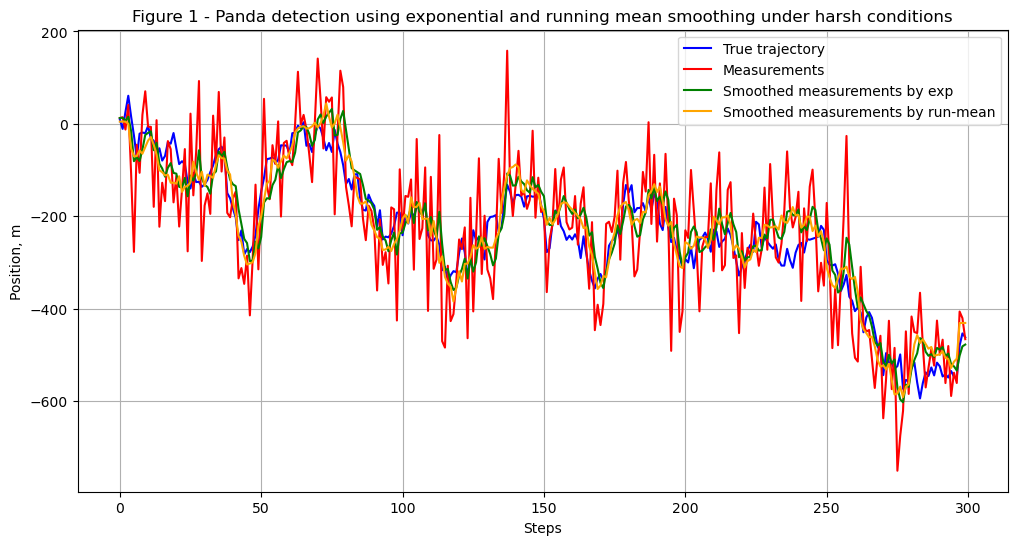

In [9]:
# plot of Panda detection using exponential and running mean smoothing under harsh conditions
plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(x_exp, color='green',  label='Smoothed measurements by exp')
plt.plot(x_mean, color='orange',  label='Smoothed measurements by run-mean')
plt.title('Figure 1 - Panda detection using exponential and running mean smoothing under harsh conditions')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

It is hard to see differences between smoothed and raw data. Let's see the same plot on a larger scale

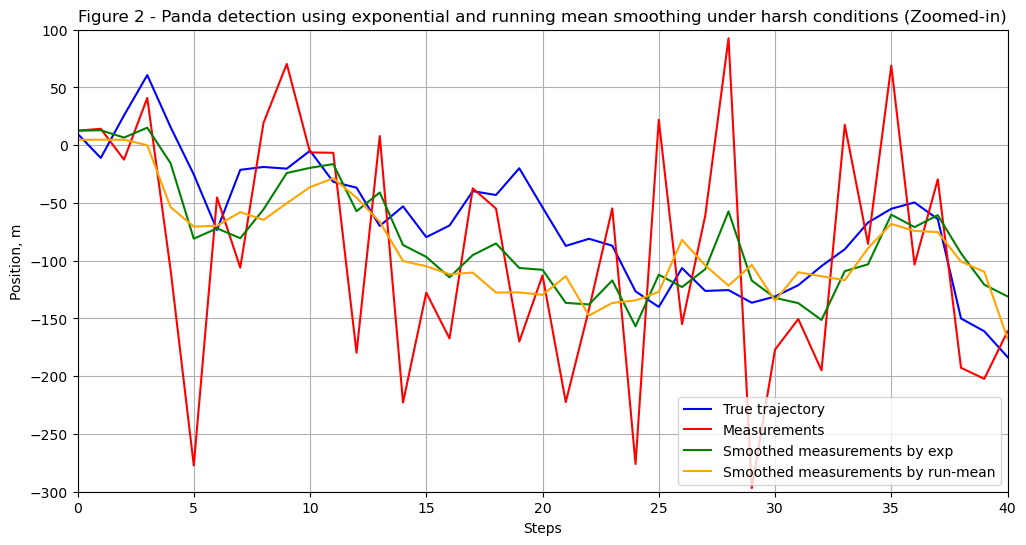

In [10]:
# plot of Panda detection using exponential and running mean smoothing under harsh conditions (Zoomed-in)
plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(x_exp, color='green',  label='Smoothed measurements by exp')
plt.plot(x_mean, color='orange',  label='Smoothed measurements by run-mean')
plt.title('Figure 2 - Panda detection using exponential and running mean smoothing under harsh conditions (Zoomed-in)')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.xlim(0,40)
plt.ylim(-300,100)
plt.grid()
plt.show()

With a lot of noise, the running mean method performs better because it has no bias, while the exponential smoothing method has bias. That is why the running mean method is closer to the true trajectory in case of harsh conditions(when noise is high).

Applying backward exponential smoothing to your forward exponential smoothing curve to further reduce measurement errors

In [11]:
# function find_backward_exp finds backward exponential smoothed trajectory
def find_backward_exp(x_fwd, al):
    n = len(x_fwd)
    x_exp_back = np.zeros(n)
    x_exp_back[n-1] = x_fwd[n-1]
    for i in range(n-2, -1, -1):
        x_exp_back[i]=x_exp_back[i+1] + al * (x_fwd[i]-x_exp_back[i+1])
    return x_exp_back

In [12]:
x_exp_back=find_backward_exp(x_exp, al)

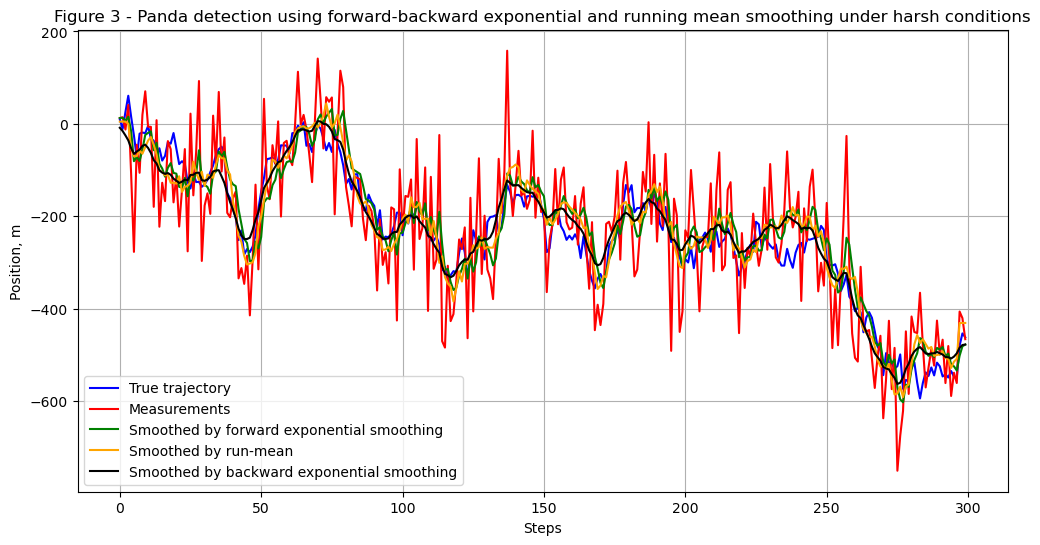

In [13]:
#plot of Panda detection using forward-backward exponential and running mean smoothing under harsh conditions
plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(x_exp, color='green',  label='Smoothed by forward exponential smoothing')
plt.plot(x_mean, color='orange',  label='Smoothed by run-mean')
plt.plot(x_exp_back, color='black', label='Smoothed by backward exponential smoothing')
plt.title('Figure 3 - Panda detection using forward-backward exponential and running mean smoothing under harsh conditions')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

It is hard to see differences between smoothed and raw data. Let's zoom in our plot

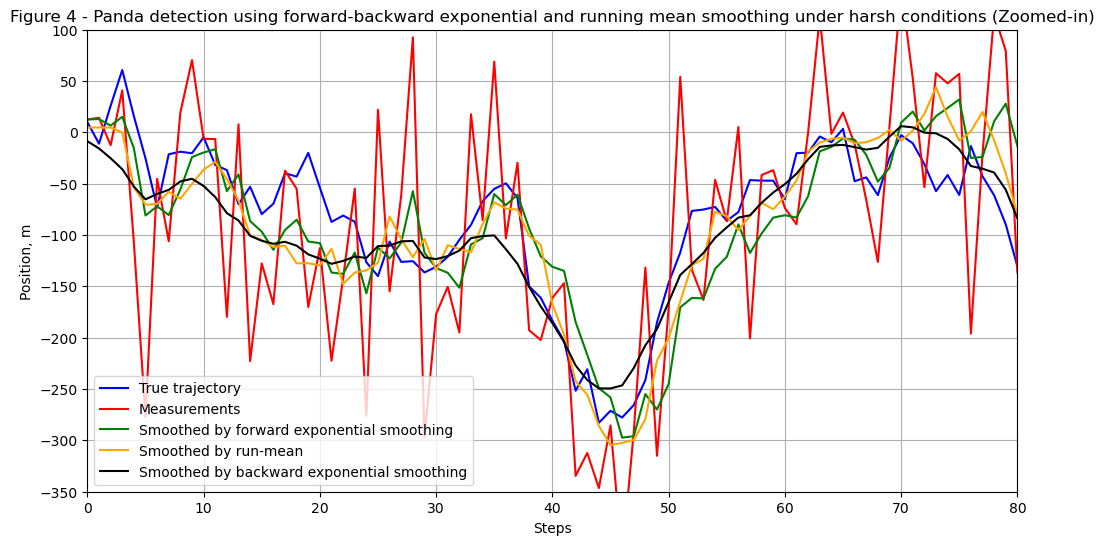

In [14]:
# plot of Panda detection using forward-backward exponential and running mean smoothing under harsh conditions (Zoomed-in)
plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(x_exp, color='green',  label='Smoothed by forward exponential smoothing')
plt.plot(x_mean, color='orange',  label='Smoothed by run-mean')
plt.plot(x_exp_back, color='black', label='Smoothed by backward exponential smoothing')
plt.title('Figure 4 - Panda detection using forward-backward exponential and running mean smoothing under harsh conditions (Zoomed-in)')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.xlim(0,80)
plt.ylim(-350,100)
plt.grid()
plt.show()

As we can see, the curve has become much smoother, and the shift has become much smaller.

Let's compare the estimation results of the running mean
and backward exponential smoothing using deviation and variability indicators

In [15]:
# function calc_indicators calculates deviation and variability indicators

def calc_indicators(z, x):
    dev_ind = np.sum((z - x) ** 2)
    n = len(z)
    var_ind = 0
    for i in range(n-2):
        var_ind += (x[i + 2] - 2 * x[i + 1] + x[i]) ** 2
    return dev_ind, var_ind

In [16]:
dev_ind_exp, var_ind_exp = calc_indicators(z, x_exp)
dev_ind_back, var_ind_back = calc_indicators(z, x_exp_back)
dev_ind_mean, var_ind_mean = calc_indicators(z, x_mean)
print(f'Deviation indicator for running mean: {dev_ind_mean}')
print(f'Variability indicator for running mean: {var_ind_mean}')
print(f'Deviation indicator for forward exponential smoothing: {dev_ind_exp}')
print(f'Variability indicator for forward exponential smoothing: {var_ind_exp}')
print(f'Deviation indicator for backward exponential smoothing: {dev_ind_back}')
print(f'Variability indicator for backward exponential smoothing: {var_ind_back}')

Deviation indicator for running mean: 2465335.077229457
Variability indicator for running mean: 233010.4215186039
Deviation indicator for forward exponential smoothing: 2060971.3041162207
Variability indicator for forward exponential smoothing: 432807.12775016157
Deviation indicator for backward exponential smoothing: 2326534.762929914
Variability indicator for backward exponential smoothing: 16149.007052675895


We see that the backward exponential smoothing gives an estimate closer to the measurements, while having a smoother trajectory than the running mean. In turn, forward exponential smoothing gives an estimate even closer to the measurements, but with a less smooth trajectory than the backward. It is confirmed by the calculated indicators

Conclusion: The backward exponential smoothing gives the curve has become much smoother, and the shift has become much smaller than the forward exponential smoothing. Also estimate closer to the measurements, while having a smoother trajectory than the running mean.

### Part II — When running mean shines, and when it stumbles

#### A. “Sun-nap stroll”: Slow change, heavy camera shake

1. Generating a **true trajectory** $X_i$ of a panda motion, perturbed by normally distributed random acceleration $a_i$ in $m/s^2$ with variance $\sigma_a^2 = 10$. The trajectory will consist of 300 points, starting with initial conditions $X_1 = 5  m$, $V_1 = 0  m/s$ and a time step $T = 0.1  s$.

$$
X_i = X_{i-1} + V_{i-1}T + \frac{a_{i-1}T^2}{2}
$$

$$
V_i = V_{i-1} + a_{i-1}T
$$

Generate measurements $z_i$ of the process $X_i$, which represents the panda motion:

$$
z_i = X_i + \eta_i
$$

$\eta_i$ is normally distributed random noise with a mean of zero and a variance of $\sigma_\eta^2 = 500$. In practice, we work with measurements obtained from various sensors and use models to analyze these measurements.

In [17]:
x = np.zeros(300)
v = np.zeros(300)
np.random.seed(45)
x[0] = 5
v[0] = 0
t = 0.1
a = np.random.normal(0, sqrt(10), 300)
for i in range(1,300):
    v[i] = v[i - 1] + a[i - 1] * t
    x[i] = x[i-1] + v[i-1] * t + (a[i - 1] * t **2) / 2
np.random.seed(45)
z = x + np.random.normal(0, sqrt(500), 300)

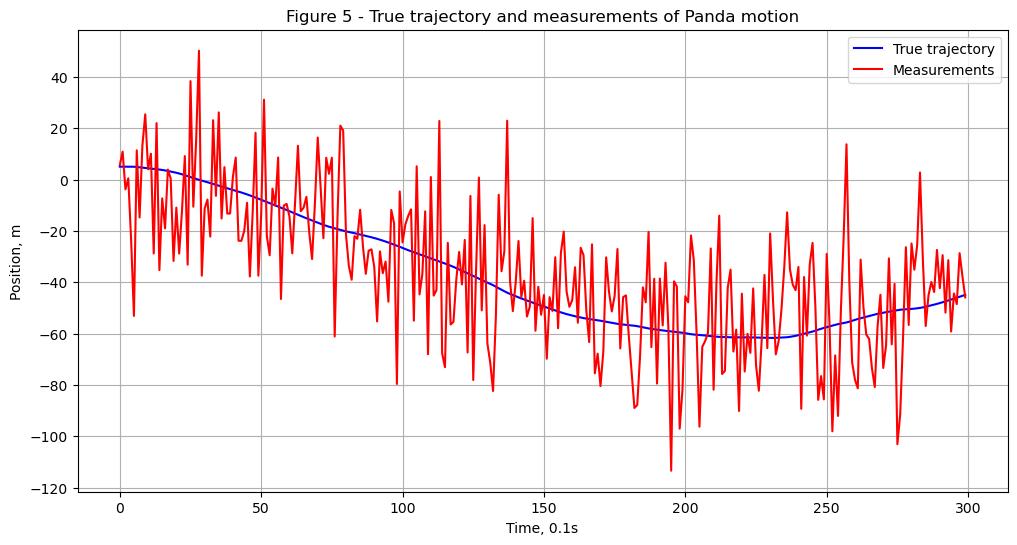

In [18]:
#plot of True trajectory and measurements of panda motion
plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.title('Figure 5 - True trajectory and measurements of Panda motion')
plt.xlabel('Time, 0.1s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

2. Empirically determine the optimal window size $𝑀$ for the running mean and the smoothing
coefficient for forward exponential smoothing to achieve the best estimation of the panda’s
motion using the measurements $z_i$.

Let's build a plot showing deviation and variability indicators depending on M

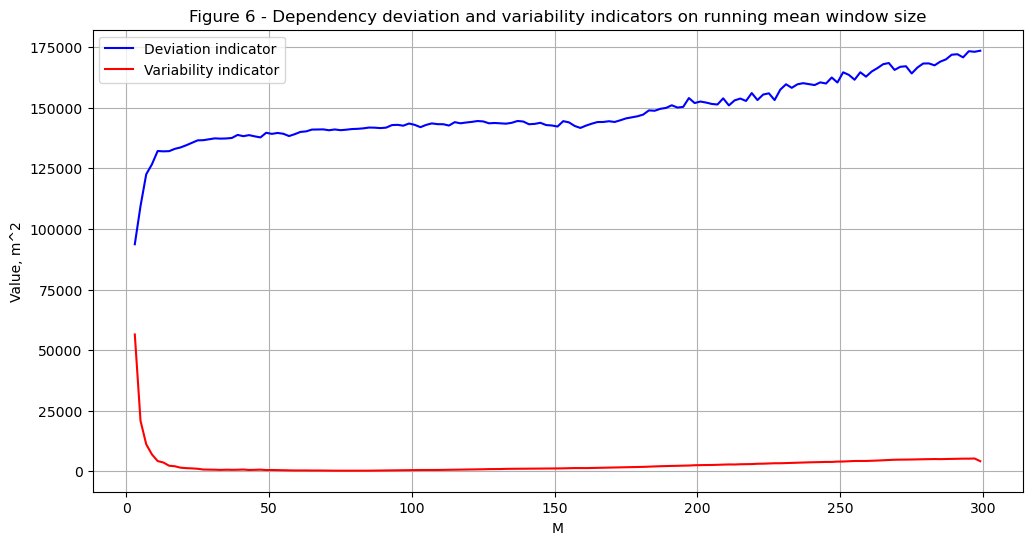

In [19]:
dev, var, M = [], [], []
for i in range(3, n+1, 2):
    x_mean=np.zeros(len(z))
    x_mean[:i//2]=(np.sum(z[0:i//2])/(i//2))
    x_mean[len(z)-(i//2):len(z)]=(np.sum(z[len(z)-(i//2):len(z)])/(i//2))
    for j in range(i//2, len(z)-(i//2)):
        x_mean[j]=(1/i)*np.sum(z[j-((i-1)//2)-1:j+((i-1)//2)])
    dev_ind, var_ind = calc_indicators(z, x_mean)
    dev.append(dev_ind)
    var.append(var_ind)
    M.append(i)
# plot showing deviation and variability indicators depending on M
plt.figure(figsize=(12, 6))
plt.plot(M, dev, color="blue",  label='Deviation indicator')
plt.plot(M, var, color='red',  label='Variability indicator')
plt.title('Figure 6 - Dependency deviation and variability indicators on running mean window size')
plt.xlabel('M')
plt.ylabel('Value, m^2')
plt.legend()
plt.grid()
plt.show()

The deviation indicator is responsible for how close our estimates are to the measurements. The variability indicator is responsible for how smooth the prediction curve is. On the one hand, we want to make it as smooth as possible, for this we need to reduce the variability indicator. On the other hand, we try to bring our estimates closer to the measurements, for this we must reduce the deviation indicator. We see that in the range M from 25 to 125, the variability indicator changes slightly. In this range, we will look for the minimum deviation indicator to determine the optimal window. In this case, we are looking for the minimum deviation indicator for the minimum variability indicator. With the minimum deviation indicator, the optimal window will be found.

In [20]:
# function window_detect determines the optimal window size for the running mean
def window_detect(z):
    n=len(z)
    dev_ind_opt = np.sum(z**2)
    for i in range(25, 125, 2):
        x_mean=np.zeros(n)
        x_mean[:i//2]=(np.sum(z[0:i//2])/(i//2))
        x_mean[n-(i//2):n]=(np.sum(z[n-(i//2):n])/(i//2))
        for j in range(i//2, n-(i//2)):
            x_mean[j]=(1/i)*np.sum(z[j-((i-1)//2)-1:j+((i-1)//2)])
        dev_ind = calc_indicators(z, x_mean)[0]
        if dev_ind < dev_ind_opt:
            dev_ind_opt = dev_ind
            M = i
    return M

In [21]:
M = window_detect(z)
print(f'Optimal window size M: {M}')

Optimal window size M: 25


Let's build a plot showing deviation and variability indicators depending on alpha

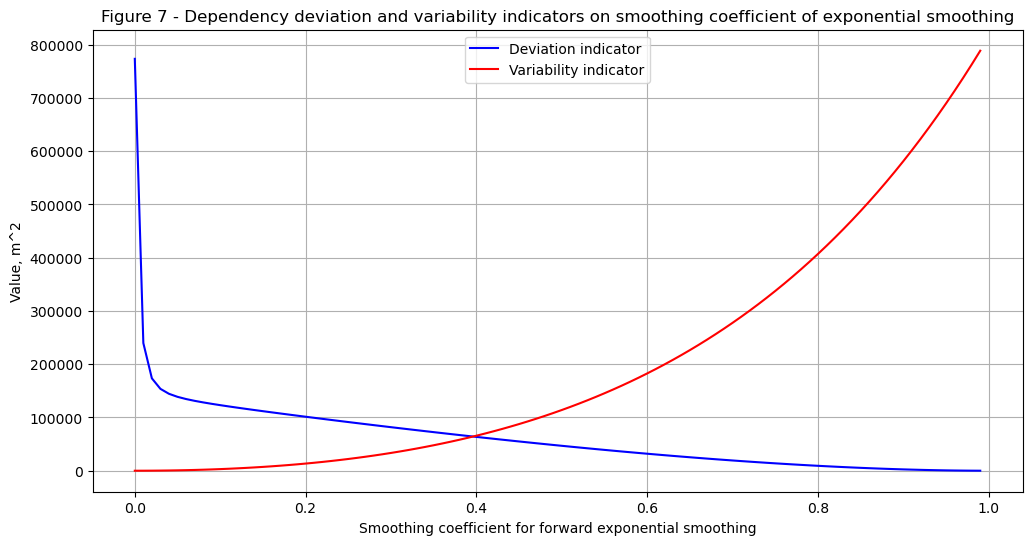

In [22]:
#plot of Dependency deviation and variability indicators on smoothing coefficient of exponential smoothing
dev, var, alpha = [], [], []
for al in np.arange(0, 1, 0.01):
    n=len(z)
    x_exp=np.zeros(n)
    x_exp[0]=z[0]
    for i in range(1,n):
        x_exp[i]=x_exp[i-1]+al*(z[i]-x_exp[i-1])
    dev_ind, var_ind = calc_indicators(z, x_exp)
    dev.append(dev_ind)
    var.append(var_ind)
    alpha.append(al)
plt.figure(figsize=(12, 6))
plt.plot(alpha, dev, color="blue",  label='Deviation indicator')
plt.plot(alpha, var, color='red',  label='Variability indicator')
plt.title('Figure 7 - Dependency deviation and variability indicators on smoothing coefficient of exponential smoothing')
plt.xlabel('Smoothing coefficient for forward exponential smoothing')
plt.ylabel('Value, m^2')
plt.legend()
plt.grid()
plt.show()

The deviation indicator is responsible for how close our estimates are to the measurements. The variability indicator is responsible for how smooth the prediction curve is. On the one hand, we want to make it as smooth as possible, for this we need to reduce the variability indicator. On the other hand, we try to bring our estimates closer to the measurements, for this we must reduce the deviation indicator. In this case, we cannot find both minimum values of the indicators, because as one decreases, the second increases. Let's find alpha as the intersection point of deviation and variability curves, because this will be a balanced value between the proximity of the estimate to the measurements and the smoothness of the estimation curve.

In [23]:
dev = np.array(dev)
var = np.array(var)
alpha_opt = alpha[np.argmin(np.abs(dev-var))]
print(f'Optimal smoothing coefficient for forward exponential smoothing: {alpha_opt}')

Optimal smoothing coefficient for forward exponential smoothing: 0.4


3. Select the more effective smoothing method based on deviation and variability indicators

Firstly, let's build plots with raw data and smoothed data.

Applying the running mean with window size 25
The first 12 points and the last 12 points are found as the average of the first 12 points and the last 12 points respectively

In [24]:
n=len(z)
x_mean=np.zeros(n)
x_mean[:12]=(np.sum(z[0:12])/12)
x_mean[n-12:n]=(np.sum(z[n-12:n])/12)
for i in range(12,n-12):
    x_mean[i]=(1/M)*np.sum(z[i-((M-1)//2)-1:i+((M-1)//2)])

Applying the exponential smoothing

In [25]:
x_exp = find_exp(z, alpha_opt)

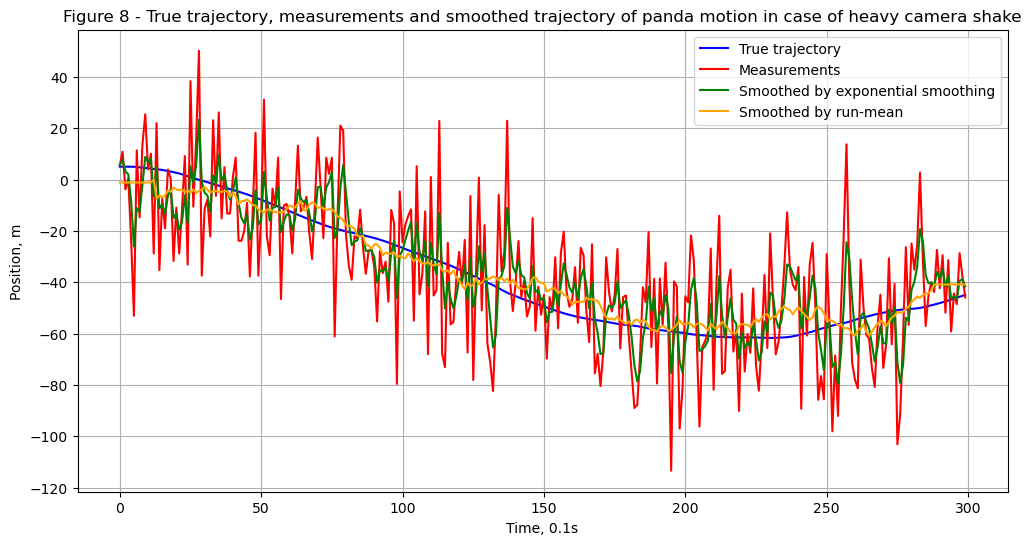

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(x_exp, color='green',  label='Smoothed by exponential smoothing')
plt.plot(x_mean, color='orange',  label='Smoothed by run-mean')
plt.title('Figure 8 - True trajectory, measurements and smoothed trajectory of panda motion in case of heavy camera shake')
plt.xlabel('Time, 0.1s')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

Secondly, find deviation and variability indicators

In [27]:
dev_ind_exp, var_ind_exp = calc_indicators(z, x_exp)
dev_ind_mean, var_ind_mean = calc_indicators(z, x_mean)
print(f'Deviation indicator for running mean: {dev_ind_mean}')
print(f'Variability indicator for running mean: {var_ind_mean}')
print(f'Deviation indicator for forward exponential smoothing: {dev_ind_exp}')
print(f'Variability indicator for forward exponential smoothing: {var_ind_exp}')

Deviation indicator for running mean: 136507.44504725322
Variability indicator for running mean: 1073.6435178442298
Deviation indicator for forward exponential smoothing: 63494.76975156131
Variability indicator for forward exponential smoothing: 65742.69547021943


We conclude that for this trajectory, the running mean method gives a stronger smoothing with an acceptable deviation relative to the exponential smoothing method. In addition, the running mean method is the closest to the true trajectory.

#### B. “Hill-slide loop”: Cyclic motion in rolling bamboo hills

Generating a cyclic trajectory $X_i$ based on the following equation:

$$
X_i = A_i \cdot \sin (\omega i + 3)
$$

Where:

$$
A_i = A_{i-1} + w_i
$$

**Key details:**
- The period of oscillation is $T = 32$ steps
- **Hint:** To determine the angular frequency $\omega$ in radians per step, use the equation $\omega T = 2\pi$ (the sine wave completes one full cycle of $2\pi$ radians in $T$ steps)
- $w_i$ represents normally distributed random noise with a mean of zero and a variance of $\sigma_w^2 = 0.08^2$
- The trajectory size should consist of 200 points
- Initial condition: Set $A_1 = 1  m$

In [28]:
omega = 2 * pi / 32
a = np.zeros(200)
x = np.zeros(200)
a[0] = 1
np.random.seed(46)
for i in range(1, 200):
    a[i] = a[i-1] + np.random.normal(0, 0.08)
    x[i] = a[i] * np.sin(omega * i + 3)

4. Generate measurements $z_i$ of the panda's cyclic motion $X_i$:

$$
z_i = X_i + \eta_i
$$

$\eta_i$ is normally distributed random noise with a mean of zero and a variance of $\sigma_{\eta}^2 = 0.05$.

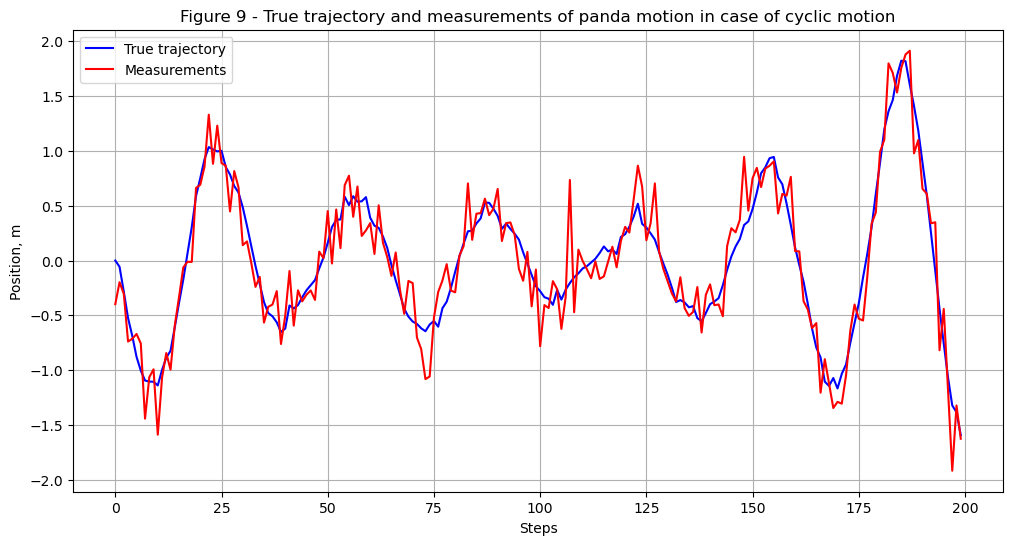

In [29]:
z = x + np.random.normal(0, sqrt(0.05), 200)

plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.title('Figure 9 - True trajectory and measurements of panda motion in case of cyclic motion')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

5. Applying running mean with a window size of $𝑀$ = 13 to the measurements $𝑧_𝑖$.

In [30]:
M = 13
n=len(z)
x_mean=np.zeros(n)
x_mean[:6]=(np.sum(z[0:6])/6)
x_mean[n-6:n]=(np.sum(z[n-6:n])/6)
for i in range(6,n-6):
    x_mean[i]=(1/M)*np.sum(z[i-((M-1)//2)-1:i+((M-1)//2)])

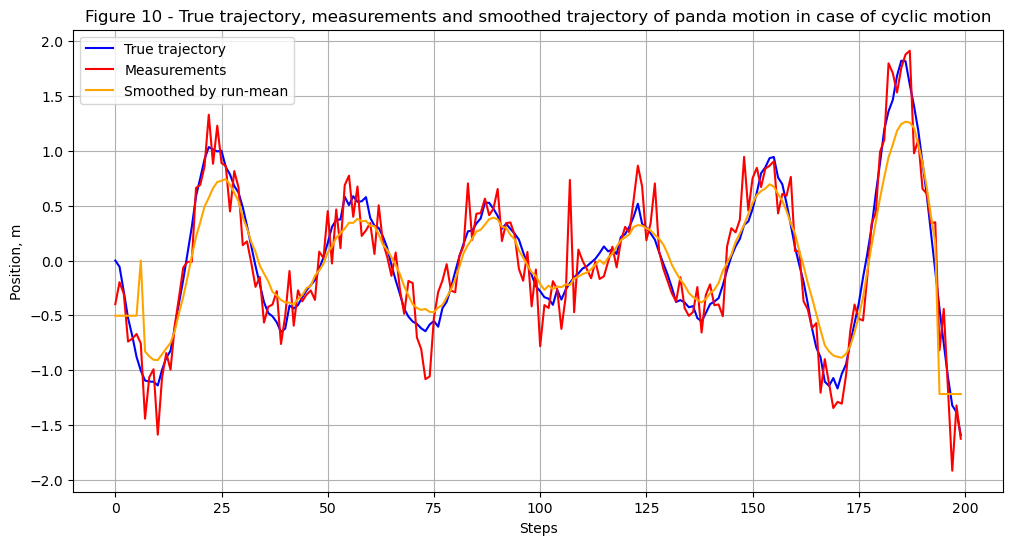

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(x, color="blue",  label='True trajectory')
plt.plot(z, color='red',  label='Measurements')
plt.plot(x_mean, color='orange',  label='Smoothed by run-mean')
plt.title('Figure 10 - True trajectory, measurements and smoothed trajectory of panda motion in case of cyclic motion')
plt.xlabel('Steps')
plt.ylabel('Position, m')
plt.legend()
plt.grid()
plt.show()

We can see that the running mean method gives acceptable results for a given period and window.

6. Determing the period of oscillations for which applying a running mean with the specified
window size 𝑀 = 21 results in the following outcomes:
    1. Produces inverse oscillations.
    2. Leads to the loss of oscillations (resulting in zero oscillations).
    3. Changes the oscillations insignificantly.

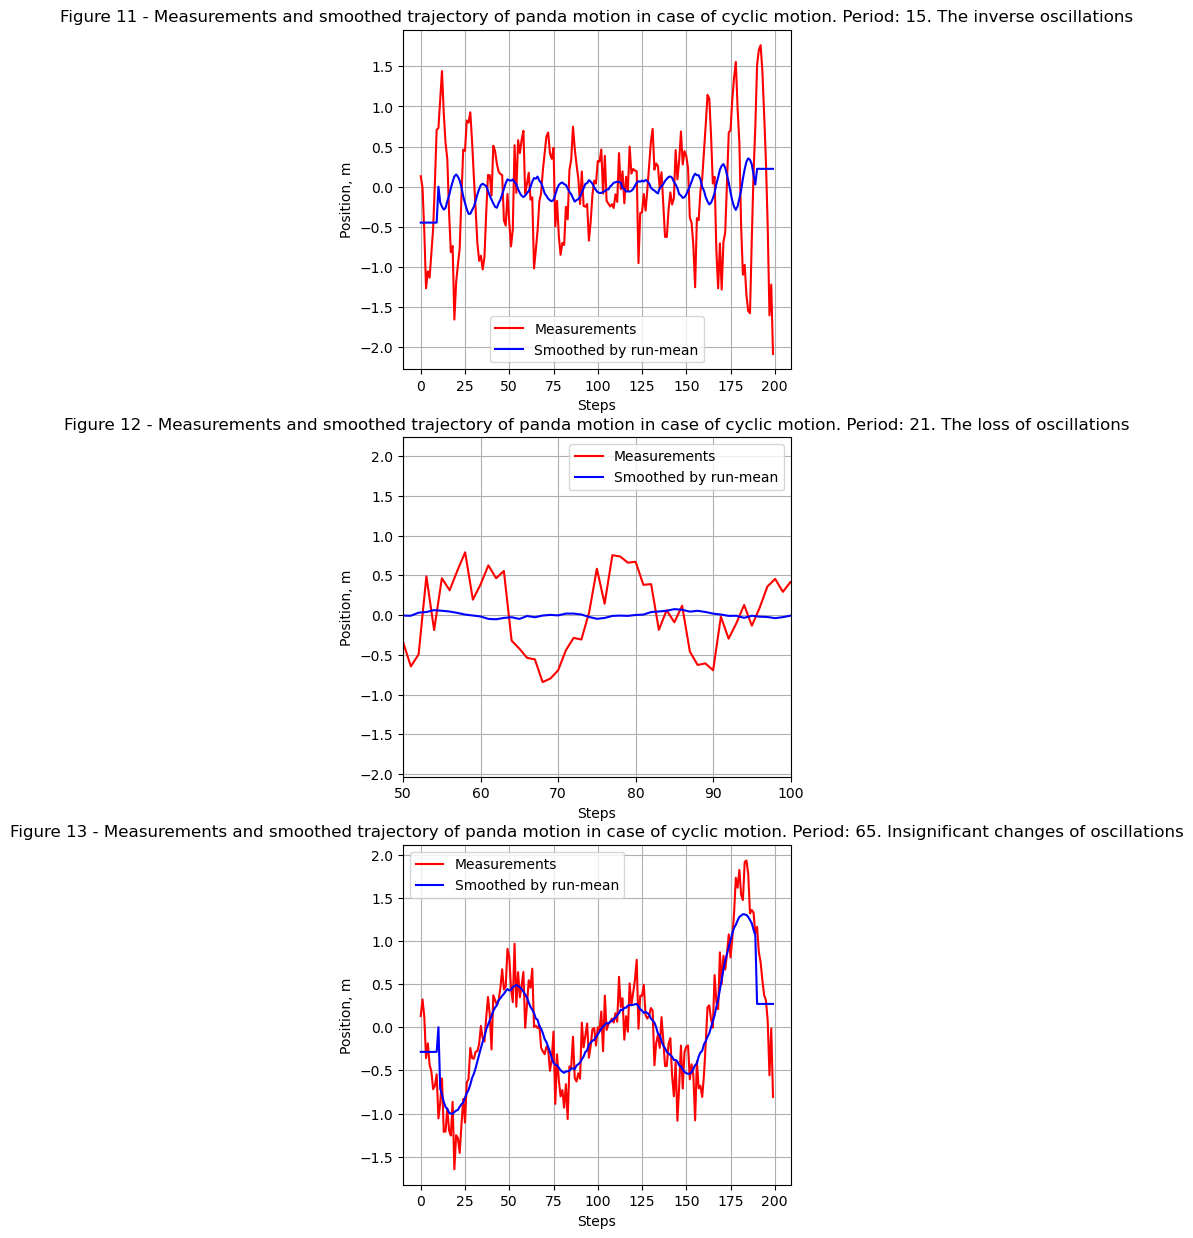

In [32]:
M = 21
plt.figure(figsize=(5, 15))
numb=0
for T in range(1, 66):
    if T in (21, 15, 65):
        numb=numb+1
        plt.subplot(3, 1, numb)
        omega = 2 * pi / T
        x = np.zeros(200)
        a[0] = 1
        np.random.seed(46)
        for i in range(1, 200):
            x[i] = a[i] * np.sin(omega * i + 3)
        z = x + np.random.normal(0, sqrt(0.05), 200)
        n=len(z)
        x_mean=np.zeros(n)
        x_mean[:10]=(np.sum(z[0:10])/10)
        x_mean[n-10:n]=(np.sum(z[n-10:n])/10)
        for i in range(10, n-10):
            x_mean[i]=(1/M)*np.sum(z[i-((M-1)//2)-1:i+((M-1)//2)])
        plt.plot(z, color='red',  label='Measurements')
        plt.plot(x_mean, color='blue',  label='Smoothed by run-mean')
        if T==21:
            plt.title(f'Figure 12 - Measurements and smoothed trajectory of panda motion in case of cyclic motion. Period: {T}. The loss of oscillations')
            plt.xlim(50, 100)
        if T==15:
            plt.title(f'Figure 11 - Measurements and smoothed trajectory of panda motion in case of cyclic motion. Period: {T}. The inverse oscillations')
        if T==65:
            plt.title(f'Figure 13 - Measurements and smoothed trajectory of panda motion in case of cyclic motion. Period: {T}. Insignificant changes of oscillations')
        plt.xlabel('Steps')
        plt.ylabel('Position, m')
        plt.legend()
        plt.grid()
plt.show()

We see that with a period of 21 steps, leads to the loss of oscillations (resulting in zero oscillations)
For period 15, produces inverse oscillations.
For period of 65 steps, changes the oscillations insignificantly.

We can conclude that the reverse oscillations appear with a period in the range from (M-1)/2 to (M - 2)
. The oscillations disappear in the vicinity of points (M-1)/2 and M. With oscillation periods several times greater than M, changes the oscillations insignificantly.


**Conclussions:**

We applied forward-backward exponential smoothing and found that the curve has become much smoother, and the shift has become much smaller than the forward exponential smoothing. Also estimate closer to the measurements, while having a smoother trajectory than the running mean.
Thus, we understand that when applying an exponential filter, we should filter on both sides to remove the bias and obtain the highest quality data. 

We have determined the optimal window for running mean and the optimal smoothing coefficient for exponential smoothing and selected the most efficient approximation method. We conclude that for this trajectory, the running mean method gives a stronger smoothing with an acceptable deviation relative to the exponential smoothing method. In addition, the running mean method is the closest to the true trajectory.

We applied the running mean method for a periodically changing signal and saw how the quality of the approximation depends on the window and period.
Thus, we can see that the period greatly influences the quality of the filtering. Thus, we can see that the period strongly affects the filtration quality. Therefore, in order to correctly apply the filter of the current average value, we must take into account the period, namely, the filter window should be on average 2 times smaller than the period.

**Learning log:**

What we learned:

We learned how to implement and apply Forward-Backward Exponential Smoothing to significantly reduce the inherent lag present in standard forward exponential smoothing. We also learned how window size affects filtering measurements.  We also strengthened our ability to compare filtering methods quantitatively using deviation and variability indicators. We learned to empirically determine the optimal parameters by analyzing the relationship between these indicators and the parameters

What difficulties we faced:

Analyzing the plots of deviation and variability indicators versus parameters (M and α) to find the true "optimal" point was challenging. It required understanding that the goal is often a balance between these two competing metrics, not just minimizing one. It was really hard to estimate the impact of the coefficient, and it was also hard to estimate the impact graphically.